In [1]:
#@title env
!pip install ultralytics kagglehub

import kagglehub
import os
import xml.etree.ElementTree as ET
import cv2

In [2]:
#@title download dtaset
path = kagglehub.dataset_download("andrewmvd/face-mask-detection")

print("Path:", path)
print("Isi:", os.listdir(path))

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Path: /kaggle/input/face-mask-detection
Isi: ['annotations', 'images']


In [3]:
#@title convert xml ke format yolo
import os
import cv2
import xml.etree.ElementTree as ET

# 1. SET PATH
image_dir = os.path.join(path, "images")
ann_dir = os.path.join(path, "annotations")

# 2. BUAT FOLDER YOLO
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)

# 3. CONVERT
count = 0
LIMIT = 500

for file in os.listdir(ann_dir):
    if count >= LIMIT:
        break

    xml_path = os.path.join(ann_dir, file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_name = root.find("filename").text
    img_path = os.path.join(image_dir, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w = img.shape[:2]

    label_name = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join("dataset/labels/train", label_name)

    has_object = False

    with open(label_path, "w") as f:
        for obj in root.findall("object"):
            label = obj.find("name").text.lower()

            if "with_mask" in label:
                cls_id = 0
            else:
                cls_id = 1

            xmin = int(obj.find("bndbox/xmin").text)
            ymin = int(obj.find("bndbox/ymin").text)
            xmax = int(obj.find("bndbox/xmax").text)
            ymax = int(obj.find("bndbox/ymax").text)

            x_center = (xmin + xmax) / 2 / w
            y_center = (ymin + ymax) / 2 / h
            bw = (xmax - xmin) / w
            bh = (ymax - ymin) / h

            f.write(f"{cls_id} {x_center} {y_center} {bw} {bh}\n")
            has_object = True

    if not has_object:
        os.remove(label_path)
        continue

    save_img_path = os.path.join("dataset/images/train", img_name)
    cv2.imwrite(save_img_path, img)

    count += 1

print("Total data:", count)

Total data: 500


In [4]:
#@title membuat data yaml
with open("data.yaml", "w") as f:
    f.write("""
train: dataset/images/train
val: dataset/images/train

nc: 2
names: ['with_mask', 'without_mask']
""")

In [5]:
import os

assert os.path.exists("dataset/images/train"), "Folder images tidak ada!"
assert len(os.listdir("dataset/images/train")) > 0, "Folder images kosong!"

In [6]:
#@title train yolo
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=5,
    imgsz=224,
    batch=8
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c94c4774aa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [13]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-5/weights/best.pt")

# evaluasi
metrics = model.val()

precision = metrics.box.p.mean()
recall = metrics.box.r.mean()
map50 = metrics.box.map50
map5095 = metrics.box.map

# pseudo accuracy (pendekatan)
accuracy = (precision + recall) / 2

print("===== HASIL EVALUASI YOLO ====")
print(f"Accuracy   : {accuracy*100:.2f}%")
print(f"Precision  : {precision*100:.2f}%")
print(f"Recall     : {recall*100:.2f}%")
print(f"mAP@50     : {map50*100:.2f}%")
print(f"mAP@50-95  : {map5095*100:.2f}%")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2121.8±905.7 MB/s, size: 241.5 KB)
val: Scanning /content/dataset/labels/train.cache... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 149.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.8it/s 17.7s
                   all        500       2463      0.717      0.511      0.571      0.315
             with_mask        454       1927      0.644      0.761      0.755      0.423
          without_mask        202        536      0.791      0.261      0.386      0.206
Speed: 0.2ms preprocess, 25.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val-2
===== HASIL EVALUASI YOLO ====
Accuracy   : 61.44%
Precision  : 71.75%
Recall     : 51.12%
mAP@5

In [ ]:
from google.colab import files
uploaded = files.upload()



image 1/1 /content/dataset/images/train/maksssksksss11.png: 160x224 11 with_masks, 34.8ms
Speed: 1.2ms preprocess, 34.8ms inference, 1.2ms postprocess per image at shape (1, 3, 160, 224)


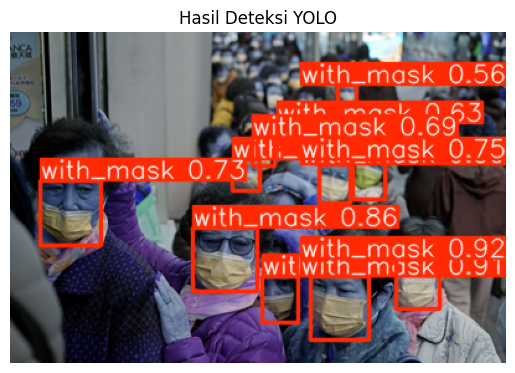

In [12]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("runs/detect/train-5/weights/best.pt")

# pilih 1 gambar test
img_path = "dataset/images/train/maksssksksss11.png"
#img_path = "WhatsApp Image 2026-04-13 at 8.12.56 PM.jpeg"
#img_path = ""

# prediksi
results = model.predict(img_path, conf=0.5)

result_img = results[0].plot()

plt.imshow(result_img)
plt.axis('off')
plt.title("Hasil Deteksi YOLO")
plt.show()